# LAB 3: Implement & Visualize BFS/DFS for a Maze Pathfinding Problem
**Relates to:** Week 3 — Uninformed Search: BFS, DFS, Iterative Deepening

## What this Lab is About
A maze is just a set of connected points. Searching it means asking: starting here, which points can I reach, and in what order should I check them?

* **Breadth-First Search (BFS)** checks everything one step away, then everything two steps away, and so on — like ripples spreading from a stone. It always finds the **shortest path**.
* **Depth-First Search (DFS)** picks one direction and runs as far as it can before backing up — like following one corridor to its dead end. It uses far less memory but may return a needlessly long path.

The only difference in code is one line: whether you take items from the front or the back of your to-do list.

## Before you Start
* Completion of Labs 1 and 2
* Understanding of Python lists, dictionaries, sets, and `while` loops
* `matplotlib` and `numpy` installed

## Step 1 — Represent the maze
We use a grid of numbers. `0` means you can walk there, `1` means it is a wall. Positions are written as `(row, column)`, counting from 0 at the top-left.

In [104]:
# Define the maze: 0 is an open path, 1 is a wall
maze = [
    [0, 0, 0, 1, 0],
    [1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
]
# maza = 3 x 3

start = (0, 0) # Top-left corner
goal = (len(maze)-1, len(maze)-1)  # Bottom-right corner

## Step 2 — Find which cells you can move to
From any cell you may move up, down, left or right. This helper checks each of the four candidates and keeps only the ones that are inside the grid and are not walls.

In [105]:
def neighbors(cell, maze):
    """Returns valid neighboring cells (up, down, left, right) that are not walls."""
    row, col = cell
    
    candidates = [
        (row - 1, col), # up
        (row + 1, col), # down
        (row, col - 1), # left
        (row, col + 1)  # right
    ]
    
    valid = []
    for r, c in candidates:
        # Check if candidate is inside grid bounds
        inside_grid = 0 <= r < len(maze) and 0 <= c < len(maze[0])
        # Check if cell is walkable (not a wall)
        if inside_grid and maze[r][c] == 0:
            valid.append((r, c))
            
    return valid

## Step 3 — Rebuild the path once you reach the goal
While searching, we record for each cell which cell we came from in a dictionary called `parent`. To get the path, we start at the goal and follow those links backwards to the start, then reverse the list.

In [106]:
def reconstruct_path(parent, start, goal):
    """Backtracks from the goal to the start using the parent dictionary."""
    path = [goal]
    while path[-1] != start:
        path.append(parent[path[-1]]) # Look up where we arrived from
    path.reverse() # Flip goal-to-start to start-to-goal
    return path

## Step 4 — Breadth-First Search (BFS)
The `frontier` is our to-do list. BFS uses `popleft()`, which removes from the FRONT — so cells discovered earliest are explored earliest, giving the level-by-level ripple effect. `visited` stops us from checking the same cell twice.

In [107]:
from collections import deque

def bfs(maze, start, goal):
    """Finds the shortest path using Breadth-First Search."""
    frontier = deque([start]) # The to-do list, using a double-ended queue
    visited = {start}         # Cells already seen (a set for fast lookups)
    parent = {}               # Remembers how we reached each cell
    
    while frontier:
        current = frontier.popleft() # <-- TAKE FROM THE FRONT (Ripple effect)
        
        if current == goal:
            return reconstruct_path(parent, start, goal), visited
            
        for nxt in neighbors(current, maze):
            if nxt not in visited:
                visited.add(nxt)
                parent[nxt] = current
                frontier.append(nxt)
                
    return None, visited # No path exists

## Step 5 — Depth-First Search (DFS)
Compare this carefully with Step 4. Everything is identical except `pop()` instead of `popleft()`. `pop()` removes from the BACK, so the most recently discovered cell is explored next — diving deep instead of spreading wide.

In [108]:
def dfs(maze, start, goal):
    """Finds a path using Depth-First Search by changing just one line."""
    frontier = [start]  # A plain list works as a stack
    visited = {start}
    parent = {}
    
    while frontier:
        current = frontier.pop() # <-- TAKE FROM THE BACK (Dive deep)
        
        if current == goal:
            return reconstruct_path(parent, start, goal), visited
            
        for nxt in neighbors(current, maze):
            if nxt not in visited:
                visited.add(nxt)
                parent[nxt] = current
                frontier.append(nxt)
                
    return None, visited

## Step 6 — Draw the result
We convert the maze into a picture where walls, explored cells, and the final path each get a different shade, then display and save it as a PNG file. We also include a color legend to explain what each shade means.

In [109]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def visualize(maze, path, visited, title, filename):
    """Draws the maze, path, and visited cells with a color legend."""
    grid = np.array(maze, dtype=float) # Convert to NumPy grid for shades
    
    for cell in visited:
        grid[cell] = 0.4 # Shade for explored cells not on final path
        
    for cell in path:
        grid[cell] = 0.8 # Shade for final path
        
    plt.figure(figsize=(6, 6))
    im = plt.imshow(grid, cmap='viridis', vmin=0, vmax=1)
    
    # Create a legend to explain grid colors
    colors = [im.cmap(0.0), im.cmap(0.4), im.cmap(0.8), im.cmap(1.0)]
    labels = ['Open Path', 'Explored', 'Final Path', 'Wall']
    patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(4)]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show() # Display image in the notebook
    print('Saved', filename)

## Step 7 — Run and Compare
Let's run both algorithms and compare their path lengths and number of cells explored.

BFS path length: 9 | cells explored: 16
DFS path length: 9 | cells explored: 11

BFS path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]
DFS path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]


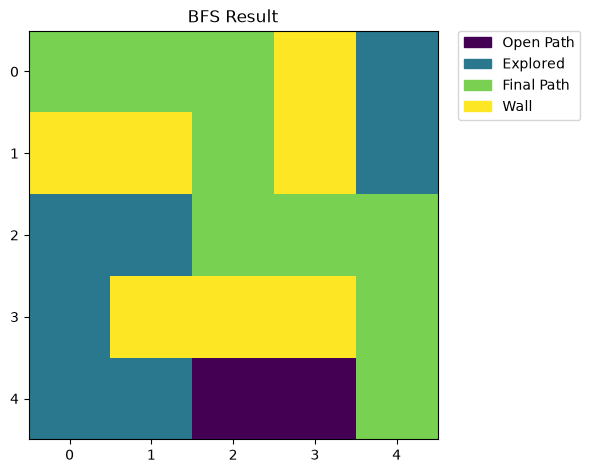

Saved lab3_bfs.png


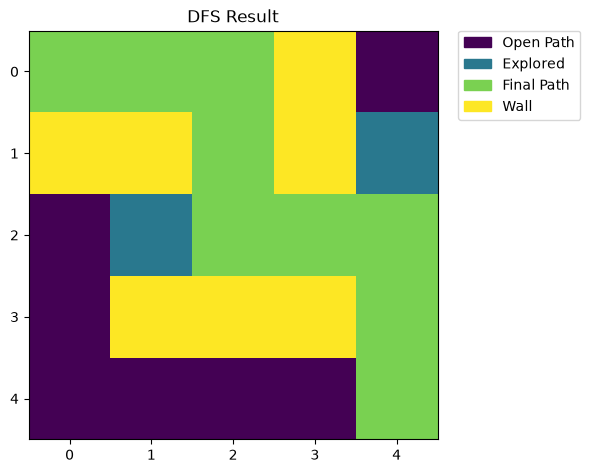

Saved lab3_dfs.png


In [110]:
bfs_path, bfs_visited = bfs(maze, start, goal)
dfs_path, dfs_visited = dfs(maze, start, goal)

print('BFS path length:', len(bfs_path), '| cells explored:', len(bfs_visited))
print('DFS path length:', len(dfs_path), '| cells explored:', len(dfs_visited))
print()
print('BFS path:', bfs_path)
print('DFS path:', dfs_path)

visualize(maze, bfs_path, bfs_visited, 'BFS Result', 'lab3_bfs.png')
visualize(maze, dfs_path, dfs_visited, 'DFS Result', 'lab3_dfs.png')

## Try It Yourself!
1. **Trace the search:** Print the order in which cells are explored inside the `while` loop (e.g. `print(current)`) to see the difference between ripple (BFS) versus dive (DFS) pattern.
2. **Bigger Maze:** Build a bigger 10x10 maze and compare the path lengths again — DFS will usually return a LONGER path than BFS.
3. **Block the path:** Block the maze completely with walls (`1`s on a diagonal) and confirm both functions return `None` gracefully.

---
# Additional Features (Random Mazes & Animations)

The functions below are helpful for visualizing how algorithms traverse step-by-step and testing them on dynamic mazes.

In [111]:
import random
from IPython.display import display, clear_output
import time

def generate_random_maze(size, wall_probability=0.3):
    """
    Generates a random size x size maze.
    - 0 represents an open path
    - 1 represents a wall
    """
    new_maze = []
    for r in range(size):
        row = []
        for c in range(size):
            if random.random() < wall_probability:
                row.append(1)
            else:
                row.append(0)
        new_maze.append(row)
        
    # Ensure start and goal are always open
    new_maze[0][0] = 0
    new_maze[size-1][size-1] = 0
    
    return new_maze

def animate_search(maze, start, goal, search_type="BFS"):
    """
    Animates the BFS or DFS search process step-by-step.
    """
    frontier = deque([start]) if search_type == "BFS" else [start]
    visited = {start}
    parent = {}
    
    fig, ax = plt.subplots(figsize=(5, 5))
    
    while frontier:
        current = frontier.popleft() if search_type == "BFS" else frontier.pop()
        
        # Visualize current state
        grid = np.array(maze, dtype=float)
        for cell in visited:
            grid[cell] = 0.4
        grid[current] = 0.8  # Highlight current cell actively being explored
        
        ax.clear()
        ax.imshow(grid, cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f"{search_type} Searching... exploring {current}")
        
        display(fig)
        clear_output(wait=True)
        time.sleep(0.1) # 0.1 second delay between frames
        
        if current == goal:
            path = reconstruct_path(parent, start, goal)
            for cell in path:
                grid[cell] = 0.8
            ax.clear()
            ax.imshow(grid, cmap='viridis', vmin=0, vmax=1)
            ax.set_title(f"{search_type} Found Goal!")
            display(fig)
            clear_output(wait=True)
            plt.close(fig)
            visualize(maze, path, visited, f'{search_type} Result', f'lab3_{search_type.lower()}.png')
            return path
            
        for nxt in neighbors(current, maze):
            if nxt not in visited:
                visited.add(nxt)
                parent[nxt] = current
                frontier.append(nxt)
                
    plt.close(fig)
    
    print(f"{search_type}: No path found.")
    visualize
    return None

# Create a random 10x10 maze
rand_maze = generate_random_maze(10, wall_probability=0.25)
rand_start = (0, 0)
rand_goal = (len(rand_maze)-1,len(rand_maze)-1)

### Watch BFS in Action:

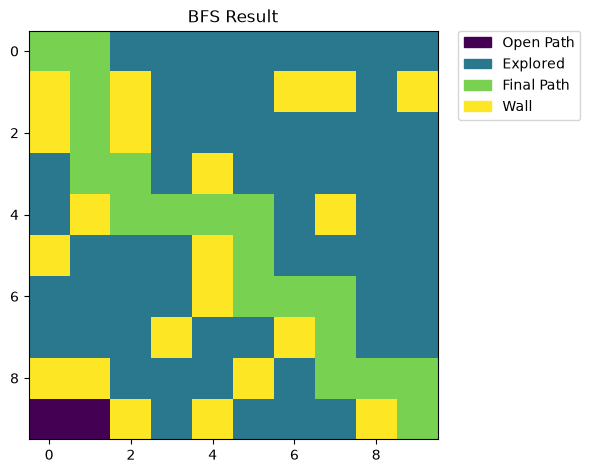

Saved lab3_bfs.png


[(0, 0),
 (0, 1),
 (1, 1),
 (2, 1),
 (3, 1),
 (3, 2),
 (4, 2),
 (4, 3),
 (4, 4),
 (4, 5),
 (5, 5),
 (6, 5),
 (6, 6),
 (6, 7),
 (7, 7),
 (8, 7),
 (8, 8),
 (8, 9),
 (9, 9)]

In [112]:
# This will animate frame-by-frame. (Interrupt the kernel to stop early if needed)
animate_search(rand_maze, rand_start, rand_goal, search_type="BFS")

  


### Watch DFS in Action:

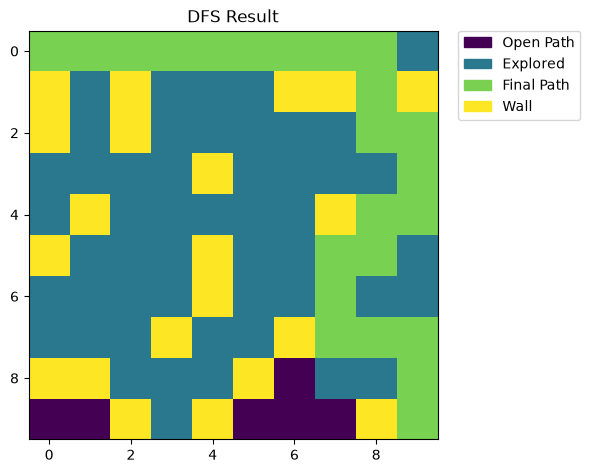

Saved lab3_dfs.png


[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (1, 8),
 (2, 8),
 (2, 9),
 (3, 9),
 (4, 9),
 (4, 8),
 (5, 8),
 (5, 7),
 (6, 7),
 (7, 7),
 (7, 8),
 (7, 9),
 (8, 9),
 (9, 9)]

In [113]:
animate_search(rand_maze, rand_start, rand_goal, search_type="DFS")